In [1]:
import os
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from networkx import config

D:\code\LangChain-lesson\My-test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# 配置环境变量
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
if not GROQ_API_KEY or GROQ_API_KEY == "your_groq_api_key_here":
    raise ValueError("Please set your GROQ_API_KEY environment variable.")
if not DEEPSEEK_API_KEY or DEEPSEEK_API_KEY == "your_deepseek_api_key_here":
    raise ValueError("Please set your DEEPSEEK_API_KEY environment variable.")
# 初始化模型
# model = init_chat_model("groq:llama-3.3-70b-versatile", api_key=GROQ_API_KEY)
model = init_chat_model("deepseek:deepseek-chat", api_key=DEEPSEEK_API_KEY)

In [3]:
# 简单顺序工作流
def simple_workflow():
    print("\n"+"="*60)
    print("Simple Workflow")
    print("="*60)

    # 定义状态
    class SimpleState(TypedDict):
        input_text: str
        processed_text: str
        llm_response:  str
        final_output: str

    # 定义节点函数
    def preprocess(state: SimpleState) -> dict:
        """预处理节点：清理和结构化输出"""
        text = state["input_text"].strip().lower()
        print(f"[预处理] 输入：'{state['input_text']}' -> '{text}'")
        return {"processed_text": text}
    def call_llm(state: SimpleState) -> dict:
        """LLM节点：调用语言模型"""
        messages = [
            SystemMessage(content="你是一个友好的助手，请简洁回答问题。"),
            HumanMessage(content=state["processed_text"])
        ]
        response = model.invoke(messages)
        print(f"[LLM] 响应：{response.content[:50]}...")
        return {"llm_response": response.content}
    def postprocess(state: SimpleState) -> dict:
        """后处理节点：格式化输出"""
        final = f"AI 恢复：{state['llm_response']}"
        return {"final_output": final}

    # 构建图
    graph = StateGraph(SimpleState)
    # 添加节点
    graph.add_node("preprocess", preprocess)
    graph.add_node("call_llm", call_llm)
    graph.add_node("postprocess", postprocess)
    # 添加边
    graph.add_edge(START, "preprocess")
    graph.add_edge("preprocess", "call_llm")
    graph.add_edge("call_llm", "postprocess")
    graph.add_edge("postprocess", END)
    # 编译图
    app = graph.compile()
    from IPython.display import display, Image
    # 渲染为图片
    display(Image(app.get_graph().draw_mermaid_png()))
    # 可视化图结构
    print("\n图结构：START -> preprocess -> call_llm -> postprocess -> END")
    # 运行
    result = app.invoke({"input_text": "什么是人工智能？"})
    return  result

In [5]:
# 带条件分支的工作流
def conditional_workflow():
    print("\n"+"="*60)
    print("Conditional Workflow")
    print("="*60)

    class ConditionalState(TypedDict):
        query: str
        query_type: str
        response: str

    def classify_query(state: ConditionalState) -> dict:
        """分类节点：判断查询类型"""
        query = state["query"].lower()

        if any(word in query for word in ["天气", "温度", "下雨"]):
            query_type = "weather"
        elif any(word in query for word in ["计算", "加", "减", "乘", "除", "等于"]):
            query_type = "math"
        else:
            query_type = "general"

        print(f"  [分类] 查询类型: {query_type}")
        return {"query_type": query_type}
    def handle_weather(state: ConditionalState) -> dict:
        """处理天气查询"""
        print("[天气处理] 执行天气查询逻辑...")
        response = "今天天气晴朗，温度 25℃，适合外出！"
        return {"response": response}
    def handle_math(state: ConditionalState) -> dict:
        """处理数字计算"""
        print("[数字处理] 执行数字计算逻辑...")
        messages = [
            SystemMessage(content="你是一个数学助手，请计算并给出结果。"),
            HumanMessage(content=state["query"])
        ]
        result = model.invoke(messages)
        return {"response": result.content}
    def handle_general(state: ConditionalState) -> dict:
        """处理通用查询"""
        print("[通用处理] 执行 LLM 调用...")
        messages = [
            SystemMessage(content="你是一个知识渊博的助手，请回答问题。"),
            HumanMessage(content=state["query"])
        ]
        result = model.invoke(messages)
        return {"response": result.content}
    def route_query(state: ConditionalState) -> Literal['weather', 'math', 'general']:
        """路由函数：返回下一个节点名称"""
        return state["query_type"]
    # 构造图
    graph = StateGraph(ConditionalState)
    # 添加节点
    graph.add_node("classify", classify_query)
    graph.add_node("weather", handle_weather)
    graph.add_node("math", handle_math)
    graph.add_node("general", handle_general)
    # 添加边
    graph.add_edge(START, "classify")
    # 添加条件边
    graph.add_conditional_edges(
        "classify",     # 从哪个节点出发
        route_query,    # 路由函数
        {   # 路由映射
            "weather": "weather",
            "math": "math",
            "general": "general"
        }
    )
    graph.add_edge("weather", END)
    graph.add_edge("math", END)
    graph.add_edge("general", END)
    # 编译
    app = graph.compile()
    # 测试
    test_queries = [
        "今天北京的天气怎么样？",
        "计算 123 加 456 等于多少？",
        "Python 是什么编程语言？"
    ]

    for query in test_queries:
        print(f"\n查询: {query}")
        result = app.invoke({"query": query})
        print(f"响应: {result['response'][:100]}...")

    return result



In [13]:
# 带内存的对话工作流
def conversation_workflow():
    print("\n"+"="*60)
    print("Conversation Workflow")
    print("="*60)

    class ConversationState(TypedDict):
        messages: Annotated[list, add_messages]
        turn_count: int

    def chat_node(state: ConversationState) -> dict:
        messages = state["messages"]
        if not any(isinstance(m, SystemMessage) for m in messages):
            messages = [
                SystemMessage(content="你是一个友好的助手，记住用户告诉你的信息。")
            ] +  messages
        # 调用模型
        response = model.invoke(messages)
        # 更新轮数
        turn_count = state.get("turn_count", 0) + 1
        print(f"[对话轮次 {turn_count}] AI：{response.content[:50]}...")
        return {
            "messages": [response],
            "turn_count": turn_count
        }
    def should_continue(state: ConversationState) -> Literal["continue", "end"]:
        """决定是否继续对话"""
        return "end"
    # 构造图
    graph = StateGraph(ConversationState)
    # 添加节点
    graph.add_node("chat", chat_node)
    # 添加边
    graph.add_edge(START, "chat")
    graph.add_edge("chat", END)
    # 使用内存保存期
    memory = MemorySaver()
    app = graph.compile(checkpointer=memory)
    config= {"configurable": {"thread_id": "user_001"}}
    conversations = [
        "你好！我叫小明。",
        "我最喜欢的编程语言是 Python。",
        "你还记得我的名字吗？",
        "我喜欢什么编程语言？"
    ]

    for user_input in conversations:
        print(f"\n用户: {user_input}")
        result = app.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config=config
        )
        print(f"AI: {result['messages'][-1].content}")

    # 查看完整对话历史
    print("\n" + "-" * 40)
    print("完整对话历史：")
    state = app.get_state(config)
    for msg in state.values["messages"]:
        role = "用户" if isinstance(msg, HumanMessage) else "AI"
        print(f"  [{role}] {msg.content[:60]}...")

    return result

In [14]:
def main():
    print("\n"+"="*70)
    print("Langguage Graphs Basics")
    print("="*70)

    simple_workflow()
    conditional_workflow()
    conversation_workflow()


Langguage Graphs Basics

Simple Workflow


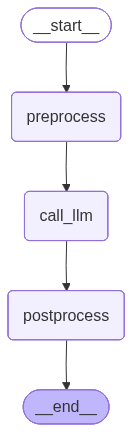


图结构：START -> preprocess -> call_llm -> postprocess -> END
[预处理] 输入：'什么是人工智能？' -> '什么是人工智能？'
[LLM] 响应：人工智能（AI）是计算机科学的一个分支，旨在开发能够模拟人类智能的系统和机器。它通过算法和数据分析，...

Conditional Workflow

查询: 今天北京的天气怎么样？
  [分类] 查询类型: weather
[天气处理] 执行天气查询逻辑...
响应: 今天天气晴朗，温度 25℃，适合外出！...

查询: 计算 123 加 456 等于多少？
  [分类] 查询类型: math
[数字处理] 执行数字计算逻辑...
响应: 123 加 456 的计算过程如下：

\[
123 + 456 = 579
\]

所以结果是 **579**。...

查询: Python 是什么编程语言？
  [分类] 查询类型: general
[通用处理] 执行 LLM 调用...
响应: Python 是一种**高级、通用、解释型**的编程语言，以其简洁易读的语法和强大的功能而广受欢迎。以下是它的主要特点：

---

### **1. 核心特性**
- **简洁易读**：语法接近英语...

Conversation Workflow

用户: 你好！我叫小明。
[对话轮次 1] AI：你好，小明！很高兴认识你。有什么我可以帮助你的吗？...
AI: 你好，小明！很高兴认识你。有什么我可以帮助你的吗？

用户: 我最喜欢的编程语言是 Python。
[对话轮次 2] AI：好的，小明！我记住了，你最喜欢的编程语言是 Python。Python 确实很受欢迎，用途也很广泛。...
AI: 好的，小明！我记住了，你最喜欢的编程语言是 Python。Python 确实很受欢迎，用途也很广泛。你平时用 Python 主要做什么呢？比如数据分析、Web 开发，还是其他方向？

用户: 你还记得我的名字吗？
[对话轮次 3] AI：当然记得！你叫小明，而且你最喜欢的编程语言是 Python。😊 需要我帮你解决 Python 相关的...
AI: 当然记得！你叫小明，而且你最喜欢的编程语言是 Python。😊 需要我帮你解决 Python 相关的问题，或者有其他想聊的吗？

In [15]:
if __name__ == "__main__":
    main()